# L5a Worked Example: Maximum Flow in a Worker–Task Network

> **Learning objectives**
>
> - Translate a constrained edge list into a source-to-sink flow network.
> - Compute maximum flow with Ford–Fulkerson and Edmonds–Karp.
> - Verify the result independently using capacity, conservation, and balance contracts.
> - Interpret a maximum-flow value as assignment throughput rather than as a path length.


## Setup, data, and prerequisites

All imports live in `Include.jl`; the edge list is meeting-local and contains `source,target,cost,lower,upper` records.


In [1]:
include(joinpath(@__DIR__, "Include.jl"))


## Task 1: Build and inspect the network


In [2]:
node_coordinates = [
    10.0 10.0;
    11.0 11.0; 11.0 10.0; 11.0 9.0;
    12.0 11.0; 12.0 10.0; 12.0 9.0; 12.0 8.0;
    13.0 11.0; 13.0 10.0; 13.0 9.0; 13.0 8.0;
    14.0 10.0;
]


13×2 Matrix{Float64}:
 10.0  10.0
 11.0  11.0
 11.0  10.0
 11.0   9.0
 12.0  11.0
 12.0  10.0
 12.0   9.0
 12.0   8.0
 13.0  11.0
 13.0  10.0
 13.0   9.0
 13.0   8.0
 14.0  10.0

In [3]:
edge_path = joinpath(CHEME5800_L5A_DATA, "Workers-Tasks-Bipartite.edgelist")
directed_graph = build_flow_graph(edge_path)


MyDirectedBipartiteGraphModel(Dict{Int64, MyGraphNodeModel}(5 => MyGraphNodeModel(5, nothing), 12 => MyGraphNodeModel(12, nothing), 8 => MyGraphNodeModel(8, nothing), 1 => MyGraphNodeModel(1, nothing), 6 => MyGraphNodeModel(6, nothing), 11 => MyGraphNodeModel(11, nothing), 9 => MyGraphNodeModel(9, nothing), 3 => MyGraphNodeModel(3, nothing), 7 => MyGraphNodeModel(7, nothing), 4 => MyGraphNodeModel(4, nothing)…), Dict{Tuple{Int64, Int64}, Number}((4, 5) => 1.0, (1, 2) => 1.0, (8, 12) => 1.0, (3, 7) => 1.0, (2, 5) => 1.0, (6, 10) => 1.0, (1, 3) => 1.0, (12, 13) => 1.0, (4, 6) => 1.0, (5, 9) => 1.0…), Dict{Int64, Set{Int64}}(5 => Set([9]), 12 => Set([13]), 8 => Set([12]), 1 => Set([4, 2, 3]), 6 => Set([10]), 11 => Set([13]), 9 => Set([13]), 3 => Set([5, 6, 7, 8]), 7 => Set([11]), 4 => Set([5, 6, 7, 8])…), Dict(5 => (2, 6), 16 => (5, 9), 20 => (9, 13), 12 => (4, 5), 8 => (3, 5), 17 => (6, 10), 1 => (1, 2), 19 => (8, 12), 22 => (11, 13), 23 => (12, 13)…), #undef, #undef, 1, 13, Dict{Tuple{I

In [4]:
function plot_flow_network(graph, coordinates; flow = Dict{Tuple{Int64, Int64}, Float64}(), title = "Flow network")
    figure = plot(; axis = nothing, border = :none, legend = false, title = title,
        xlim = (9.5, 14.5), ylim = (7.5, 11.5), size = (850, 450))
    for edge in values(graph.edgesinverse)
        s, t = edge
        value = get(flow, edge, 0.0)
        color, width = value > 1e-8 ? (:crimson, 3) : (:gray85, 1.5)
        plot!([coordinates[s, 1], coordinates[t, 1]], [coordinates[s, 2], coordinates[t, 2]];
            arrow = true, color = color, lw = width, label = "")
        midpoint = ((coordinates[s, 1] + coordinates[t, 1]) / 2,
                    (coordinates[s, 2] + coordinates[t, 2]) / 2)
        upper = graph.capacity[edge][2]
        annotate!(midpoint[1], midpoint[2] + 0.12, text("$(round(value; digits=1))/$(upper)", 7, color))
    end
    scatter!(coordinates[:, 1], coordinates[:, 2]; c = :slategray, ms = 13, label = "")
    scatter!([coordinates[1, 1], coordinates[13, 1]], [coordinates[1, 2], coordinates[13, 2]];
        c = [:seagreen, :firebrick], ms = 15, label = "")
    for vertex in axes(coordinates, 1)
        annotate!(coordinates[vertex, 1], coordinates[vertex, 2], text(string(vertex), 8, :white))
    end
    return figure
end


plot_flow_network (generic function with 1 method)

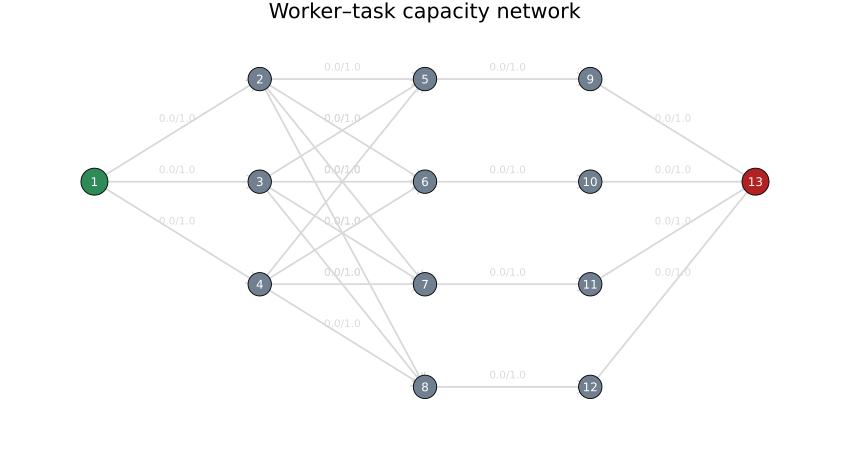

In [5]:
plot_flow_network(directed_graph, node_coordinates; title = "Worker–task capacity network")


The source can send one unit to each of three workers. Four tasks are available, but worker capacity limits the default network to at most three completed assignments. That is an upper-bound argument; the algorithm must still find a feasible flow of value three.


## Task 2: Compute and independently validate maximum flow


In [6]:
ford_value, ford_flow = maximumflow(
    directed_graph, directed_graph.nodes[1], directed_graph.nodes[13];
    algorithm = FordFulkersonAlgorithm(),
)
edmonds_value, edmonds_flow = maximumflow(
    directed_graph, directed_graph.nodes[1], directed_graph.nodes[13];
    algorithm = EdmondsKarpAlgorithm(),
)

ford_report = validate_flow(directed_graph, ford_flow, 1, 13)
edmonds_report = validate_flow(directed_graph, edmonds_flow, 1, 13)

algorithm_results = DataFrame(
    algorithm = ["Ford–Fulkerson", "Edmonds–Karp"],
    maximum_flow = [ford_value, edmonds_value],
    capacity_ok = [ford_report.capacity_ok, edmonds_report.capacity_ok],
    conservation_ok = [ford_report.conservation_ok, edmonds_report.conservation_ok],
    valid = [ford_report.valid, edmonds_report.valid],
)
pretty_table(algorithm_results)


┌────────────────┬──────────────┬─────────────┬─────────────────┬───────┐
│      algorithm │ maximum_flow │ capacity_ok │ conservation_ok │ valid │
│         String │      Float64 │        Bool │            Bool │  Bool │
├────────────────┼──────────────┼─────────────┼─────────────────┼───────┤
│ Ford–Fulkerson │          3.0 │        true │            true │  true │
│   Edmonds–Karp │          3.0 │        true │            true │  true │
└────────────────┴──────────────┴─────────────┴─────────────────┴───────┘


In [7]:
@test ford_value == 3.0
@test edmonds_value == ford_value
@test ford_report.valid && edmonds_report.valid
:maximum_flow_verified


:maximum_flow_verified

Different augmenting paths may produce different edge-level flows. The objective value and feasibility contracts must agree.


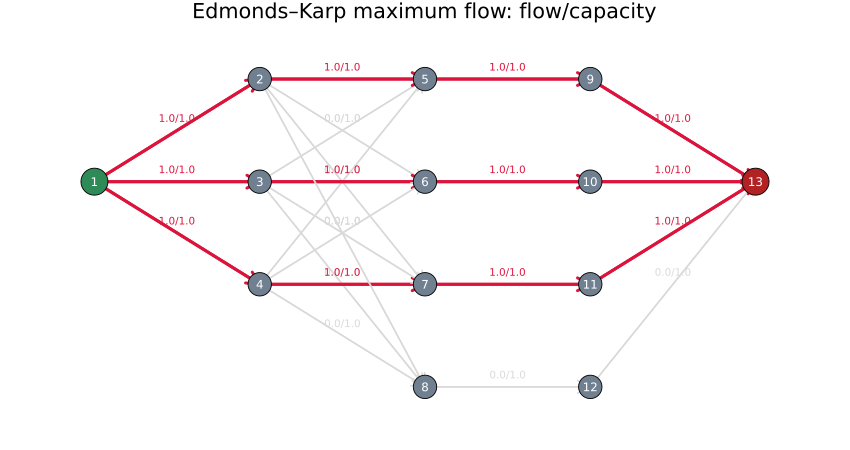

In [8]:
plot_flow_network(directed_graph, node_coordinates; flow = edmonds_flow, title = "Edmonds–Karp maximum flow: flow/capacity")


## Summary

The network completes three assignments. The unused fourth task is not evidence of an algorithm failure: three unit-capacity source-to-worker edges form a cut of capacity three. Both algorithms attain that bound, and the independent validator confirms every edge and node contract.
